In [1]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
df = pd.read_excel(
    r'C:\Users\Admin\Downloads\Machine-Learning\03-Classification\default of credit card clients.xls', 
    header=1
)

In [3]:
df.head().T

,0,1,2,3,4
ID,1,2,3,4,5
LIMIT_BAL,20000,120000,90000,50000,50000
SEX,2,2,2,2,1
EDUCATION,2,2,2,2,2
MARRIAGE,1,2,2,1,1
AGE,24,26,34,37,57
PAY_0,2,-1,0,0,-1
PAY_2,2,2,0,0,0
PAY_3,-1,0,0,0,-1
PAY_4,-1,0,0,0,0


In [4]:
df.dtypes

ID                            int64
LIMIT_BAL                     int64
SEX                           int64
EDUCATION                     int64
MARRIAGE                      int64
AGE                           int64
PAY_0                         int64
PAY_2                         int64
PAY_3                         int64
PAY_4                         int64
PAY_5                         int64
PAY_6                         int64
BILL_AMT1                     int64
BILL_AMT2                     int64
BILL_AMT3                     int64
BILL_AMT4                     int64
BILL_AMT5                     int64
BILL_AMT6                     int64
PAY_AMT1                      int64
PAY_AMT2                      int64
PAY_AMT3                      int64
PAY_AMT4                      int64
PAY_AMT5                      int64
PAY_AMT6                      int64
default payment next month    int64
dtype: object

In [5]:
df = df.drop('ID', axis=1)

In [6]:
df.head().T

,0,1,2,3,4
LIMIT_BAL,20000,120000,90000,50000,50000
SEX,2,2,2,2,1
EDUCATION,2,2,2,2,2
MARRIAGE,1,2,2,1,1
AGE,24,26,34,37,57
PAY_0,2,-1,0,0,-1
PAY_2,2,2,0,0,0
PAY_3,-1,0,0,0,-1
PAY_4,-1,0,0,0,0
PAY_5,-2,0,0,0,0


In [7]:
df.columns = df.columns.str.lower().str.replace(' ','_')
df.columns

Index(['limit_bal', 'sex', 'education', 'marriage', 'age', 'pay_0', 'pay_2',
       'pay_3', 'pay_4', 'pay_5', 'pay_6', 'bill_amt1', 'bill_amt2',
       'bill_amt3', 'bill_amt4', 'bill_amt5', 'bill_amt6', 'pay_amt1',
       'pay_amt2', 'pay_amt3', 'pay_amt4', 'pay_amt5', 'pay_amt6',
       'default_payment_next_month'],
      dtype='object')

In [8]:
df['default_payment_next_month'].value_counts()

default_payment_next_month
0    23364
1     6636
Name: count, dtype: int64

In [9]:
df['default_payment_next_month'].value_counts(normalize=True)

default_payment_next_month
0    0.7788
1    0.2212
Name: proportion, dtype: float64

In [11]:
global_mean = df.default_payment_next_month.mean()
global_mean

np.float64(0.2212)

In [12]:
categorical = [
    'sex',
    'education',
    'marriage',
    'pay_0',
    'pay_2',
    'pay_3',
    'pay_4',
    'pay_5',
    'pay_6'
]

In [13]:
numerical = [
    'limit_bal',
    'age',
    'bill_amt1',
    'bill_amt2',
    'bill_amt3',
    'bill_amt4',
    'bill_amt5',
    'bill_amt6',
    'pay_amt1',
    'pay_amt2',
    'pay_amt3',
    'pay_amt4',
    'pay_amt5',
    'pay_amt6'
]

### Train / Validation/ Test split

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

len(df_train), len(df_val), len(df_test)

(18000, 6000, 6000)

In [16]:
y_train = df_train.default_payment_next_month.values
y_val = df_val.default_payment_next_month.values
y_test = df.default_payment_next_month.values

In [17]:
del df_train['default_payment_next_month']
del df_val['default_payment_next_month']
del df_test['default_payment_next_month']

### Feature Importance

In [18]:
from IPython.display import display

In [19]:
for c in categorical:
    print(c)

    df_group = df_full_train.groupby(c).default_payment_next_month.agg(['mean', 'count'])

    df_group['diff'] = df_group['mean'] - global_mean
    df_group['risk'] = df_group['mean'] / global_mean

    display(df_group)
    print()

sex


,mean,count,diff,risk
sex,,,,
1,0.238577,9498,0.017377,1.078556
2,0.209144,14502,-0.012056,0.945495



education


,mean,count,diff,risk
education,,,,
0,0.000000,11,-0.221200,0.000000
1,0.193659,8453,-0.027541,0.875493
2,0.234445,11218,0.013245,1.059876
3,0.254357,3959,0.033157,1.149897
4,0.044444,90,-0.176756,0.200924
5,0.068966,232,-0.152234,0.311779
6,0.135135,37,-0.086065,0.610918



marriage


,mean,count,diff,risk
marriage,,,,
0,0.113636,44,-0.107564,0.513727
1,0.234771,10917,0.013571,1.061354
2,0.208509,12786,-0.012691,0.942628
3,0.256917,253,0.035717,1.161469



pay_0


,mean,count,diff,risk
pay_0,,,,
-2,0.128101,2217,-0.093099,0.579119
-1,0.171958,4536,-0.049242,0.777385
0,0.125915,11754,-0.095285,0.569234
1,0.337280,2956,0.116080,1.524774
2,0.688540,2164,0.467340,3.112747
3,0.768627,255,0.547427,3.474808
4,0.683333,60,0.462133,3.089210
5,0.434783,23,0.213583,1.965563
6,0.500000,8,0.278800,2.260398



pay_2


,mean,count,diff,risk
pay_2,,,,
-2,0.180112,3037,-0.041088,0.814249
-1,0.160677,4842,-0.060523,0.726390
0,0.156933,12534,-0.064267,0.709463
1,0.227273,22,0.006073,1.027454
2,0.557542,3189,0.336342,2.520531
3,0.634146,246,0.412946,2.866846
4,0.475610,82,0.254410,2.150135
5,0.529412,17,0.308212,2.393362
6,0.727273,11,0.506073,3.287851



pay_3


,mean,count,diff,risk
pay_3,,,,
-2,0.184676,3276,-0.036524,0.834884
-1,0.158094,4744,-0.063106,0.714713
0,0.173782,12602,-0.047418,0.785633
1,0.500000,2,0.278800,2.260398
2,0.515092,3048,0.293892,2.328625
3,0.529703,202,0.308503,2.394679
4,0.548387,62,0.327187,2.479146
5,0.500000,18,0.278800,2.260398
6,0.608696,23,0.387496,2.751789



pay_4


,mean,count,diff,risk
pay_4,,,,
-2,0.190914,3478,-0.030286,0.863085
-1,0.160922,4555,-0.060278,0.727496
0,0.182074,13143,-0.039126,0.823120
1,1.000000,1,0.778800,4.520796
2,0.525384,2541,0.304184,2.375152
3,0.557143,140,0.335943,2.518729
4,0.672414,58,0.451214,3.039845
5,0.515152,33,0.293952,2.328895
6,0.500000,4,0.278800,2.260398



pay_5


,mean,count,diff,risk
pay_5,,,,
-2,0.196208,3639,-0.024992,0.887015
-1,0.162144,4422,-0.059056,0.733019
0,0.188017,13552,-0.033183,0.849984
2,0.540028,2111,0.318828,2.441358
3,0.628571,140,0.407371,2.841643
4,0.605634,71,0.384434,2.737947
5,0.600000,15,0.378800,2.712477
6,0.666667,3,0.445467,3.013864
7,0.804348,46,0.583148,3.636292



pay_6


,mean,count,diff,risk
pay_6,,,,
-2,0.198774,3914,-0.022426,0.898615
-1,0.171851,4597,-0.049349,0.776904
0,0.188081,13021,-0.033119,0.850275
2,0.503383,2217,0.282183,2.275691
3,0.638158,152,0.416958,2.884981
4,0.621622,37,0.400422,2.810224
5,0.500000,8,0.278800,2.260398
6,0.764706,17,0.543506,3.457079
7,0.771429,35,0.550229,3.487471


### Mutual Information

In [20]:
from sklearn.metrics import mutual_info_score

In [21]:
def calculate_mi(series):
    return mutual_info_score(series, df_full_train.default_payment_next_month)

In [22]:
df_mi = df_full_train[categorical].apply(calculate_mi)

df_mi = df_mi.sort_values(ascending=False)

df_mi

pay_0        0.076832
pay_2        0.050237
pay_3        0.036600
pay_4        0.032810
pay_5        0.030289
pay_6        0.025822
education    0.002990
marriage     0.000601
sex          0.000598
dtype: float64

### Numerical values -  Correlation

In [23]:
df_full_train[numerical].corrwith(df_full_train.default_payment_next_month).sort_values()

limit_bal   -0.149247
pay_amt1    -0.071736
pay_amt2    -0.058978
pay_amt5    -0.055625
pay_amt4    -0.055338
pay_amt3    -0.054129
pay_amt6    -0.050185
bill_amt1   -0.019395
bill_amt2   -0.014530
bill_amt3   -0.013861
bill_amt4   -0.008645
bill_amt5   -0.005683
bill_amt6   -0.005330
age          0.016778
dtype: float64

In [24]:
df_full_train[numerical].corrwith(df_full_train.default_payment_next_month).sort_values().abs()

limit_bal    0.149247
pay_amt1     0.071736
pay_amt2     0.058978
pay_amt5     0.055625
pay_amt4     0.055338
pay_amt3     0.054129
pay_amt6     0.050185
bill_amt1    0.019395
bill_amt2    0.014530
bill_amt3    0.013861
bill_amt4    0.008645
bill_amt5    0.005683
bill_amt6    0.005330
age          0.016778
dtype: float64

### Numerical features-groupby mean

In [26]:
for c in numerical:
    print(c)

    df_group = df_full_train.groupby('default_payment_next_month')[c].mean()

    print(df_group)
    print()

limit_bal
default_payment_next_month
0    177421.314368
1    130865.763352
Name: limit_bal, dtype: float64

age
default_payment_next_month
0    35.406609
1    35.779015
Name: age, dtype: float64

bill_amt1
default_payment_next_month
0    51680.032619
1    48255.749198
Name: bill_amt1, dtype: float64

bill_amt2
default_payment_next_month
0    49441.492861
1    46963.141725
Name: bill_amt2, dtype: float64

bill_amt3
default_payment_next_month
0    47203.911181
1    44924.714852
Name: bill_amt3, dtype: float64

bill_amt4
default_payment_next_month
0    43289.813914
1    41957.925646
Name: bill_amt4, dtype: float64

bill_amt5
default_payment_next_month
0    40209.586974
1    39380.652387
Name: bill_amt5, dtype: float64

bill_amt6
default_payment_next_month
0    38824.078498
1    38060.701453
Name: bill_amt6, dtype: float64

pay_amt1
default_payment_next_month
0    6260.571895
1    3390.371202
Name: pay_amt1, dtype: float64

pay_amt2
default_payment_next_month
0    6545.672103
1    3459.985

### Data for Logistic Regression

In [27]:
from sklearn.feature_extraction import DictVectorizer

In [28]:
features =  categorical + numerical

In [30]:
train_dicts = df_train[features].to_dict(orient='records')
val_dicts = df_val[features].to_dict(orient='records')

In [31]:
dv = DictVectorizer(sparse=False)

X_train = dv.fit_transform(train_dicts)
X_val = dv.transform(val_dicts)

In [32]:
X_train.shape, X_val.shape

((18000, 23), (6000, 23))

### Train Logistic Regression

In [33]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(solver='liblinear', random_state=1)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,1
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


### Predict Probabilities

In [34]:
y_pred = model.predict_proba(X_val)
y_pred[:5]

array([[0.90485992, 0.09514008],
       [0.67227865, 0.32772135],
       [0.85696126, 0.14303874],
       [0.75991114, 0.24008886],
       [0.60801007, 0.39198993]])

### Convert Probability

In [35]:
default = y_pred >= 0.5

In [36]:
default.astype(int)[:10]

array([[1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0]])

In [37]:
y_pred = model.predict_proba(X_val)[:, 1]

In [38]:
default = y_pred >= 0.5

In [39]:
(default == y_val).mean()*100

np.float64(77.98333333333333)

In [40]:
model.intercept_

array([-0.00057815])

In [41]:
dict(zip(dv.get_feature_names_out(), model.coef_[0]))

{'age': np.float64(-0.014859009711545986),
 'bill_amt1': np.float64(-9.007806347045946e-06),
 'bill_amt2': np.float64(5.270058258291009e-06),
 'bill_amt3': np.float64(6.352463005911346e-07),
 'bill_amt4': np.float64(1.330887600508049e-06),
 'bill_amt5': np.float64(3.812714116010775e-06),
 'bill_amt6': np.float64(2.384178539815484e-06),
 'education': np.float64(-0.0012221954311777041),
 'limit_bal': np.float64(-3.346789051292597e-06),
 'marriage': np.float64(-0.0011491102442468593),
 'pay_0': np.float64(0.002044382483052068),
 'pay_2': np.float64(0.0016329721438042926),
 'pay_3': np.float64(0.0013836946260428922),
 'pay_4': np.float64(0.0012504992229922462),
 'pay_5': np.float64(0.0011530237368337962),
 'pay_6': np.float64(0.0010826739510828524),
 'pay_amt1': np.float64(-3.271200420596738e-05),
 'pay_amt2': np.float64(-1.3331174218347771e-05),
 'pay_amt3': np.float64(-9.227224473693302e-06),
 'pay_amt4': np.float64(-6.915311595430079e-06),
 'pay_amt5': np.float64(-8.867327725410323e-06)

In [42]:
model.coef_

array([[-1.48590097e-02, -9.00780635e-06,  5.27005826e-06,
         6.35246301e-07,  1.33088760e-06,  3.81271412e-06,
         2.38417854e-06, -1.22219543e-03, -3.34678905e-06,
        -1.14911024e-03,  2.04438248e-03,  1.63297214e-03,
         1.38369463e-03,  1.25049922e-03,  1.15302374e-03,
         1.08267395e-03, -3.27120042e-05, -1.33311742e-05,
        -9.22722447e-06, -6.91531160e-06, -8.86732773e-06,
        -6.93154246e-07, -1.04501761e-03]])

In [44]:
sorted(
    zip(dv.get_feature_names_out(), model.coef_[0]),
    key=lambda x: x[1]
)

[('age', np.float64(-0.014859009711545986)),
 ('education', np.float64(-0.0012221954311777041)),
 ('marriage', np.float64(-0.0011491102442468593)),
 ('sex', np.float64(-0.001045017609536767)),
 ('pay_amt1', np.float64(-3.271200420596738e-05)),
 ('pay_amt2', np.float64(-1.3331174218347771e-05)),
 ('pay_amt3', np.float64(-9.227224473693302e-06)),
 ('bill_amt1', np.float64(-9.007806347045946e-06)),
 ('pay_amt5', np.float64(-8.867327725410323e-06)),
 ('pay_amt4', np.float64(-6.915311595430079e-06)),
 ('limit_bal', np.float64(-3.346789051292597e-06)),
 ('pay_amt6', np.float64(-6.931542459344583e-07)),
 ('bill_amt3', np.float64(6.352463005911346e-07)),
 ('bill_amt4', np.float64(1.330887600508049e-06)),
 ('bill_amt6', np.float64(2.384178539815484e-06)),
 ('bill_amt5', np.float64(3.812714116010775e-06)),
 ('bill_amt2', np.float64(5.270058258291009e-06)),
 ('pay_6', np.float64(0.0010826739510828524)),
 ('pay_5', np.float64(0.0011530237368337962)),
 ('pay_4', np.float64(0.0012504992229922462)),


### Make a small model

In [45]:
small = ['limit_bal', 'age', 'pay_0']

In [47]:
train_dicts_small = df_train[small].to_dict(orient='records')
val_dicts_small = df_val[small].to_dict(orient='records')

In [48]:
dv_small = DictVectorizer(sparse=False)

X_train_small = dv_small.fit_transform(train_dicts_small)
X_val_small = dv_small.transform(val_dicts_small)

In [49]:
model_small = LogisticRegression(solver='liblinear', random_state=1)

model_small.fit(X_train_small, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,1
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [50]:
y_pred_small = model_small.predict_proba(X_val_small)[:, 1]

In [51]:
default_small = y_pred_small >= 0.5

In [52]:
(default_small == y_val).mean()

np.float64(0.7798333333333334)

### Individual Customer prediction

In [53]:
customer = df_val.iloc[0].to_dict()
customer

{'limit_bal': 240000,
 'sex': 2,
 'education': 1,
 'marriage': 1,
 'age': 41,
 'pay_0': -1,
 'pay_2': -1,
 'pay_3': -1,
 'pay_4': -1,
 'pay_5': -1,
 'pay_6': -1,
 'bill_amt1': 4420,
 'bill_amt2': 16829,
 'bill_amt3': 4745,
 'bill_amt4': 2430,
 'bill_amt5': 7792,
 'bill_amt6': 33196,
 'pay_amt1': 16920,
 'pay_amt2': 4774,
 'pay_amt3': 2442,
 'pay_amt4': 7829,
 'pay_amt5': 33361,
 'pay_amt6': 1076}

In [54]:
X_customer = dv.transform([customer])

In [55]:
probability = model.predict_proba(X_customer)[0,1]

probability

np.float64(0.09514008254376743)

In [56]:
print('Actual:', y_val[0])
print('Probability of default:', probability)
print('Prediction:', int(probability >= 0.5))

Actual: 0
Probability of default: 0.09514008254376743
Prediction: 0


### Testing the model

In [57]:
test_dicts = df_test[features].to_dict(orient='records')

X_test = dv.transform(test_dicts)

In [58]:
y_pred_test = model.predict_proba(X_test)[:, 1]

In [59]:
default_test = y_pred_test >= 0.5

In [63]:
comparsion = pd.DataFrame({
    'Actual': y_test[:10],
    'Predicted': default_test[:10].astype(int),
    'Probability': y_pred_test[:10]
})

comparsion

,Actual,Predicted,Probability
0,1,0,0.094888
1,1,0,0.311349
2,0,0,0.192114
3,0,0,0.270252
4,0,0,0.189713
5,0,0,0.261034
6,0,0,0.189066
7,0,0,0.263214
8,0,0,0.380550
9,0,0,0.199881


### Final Visualization

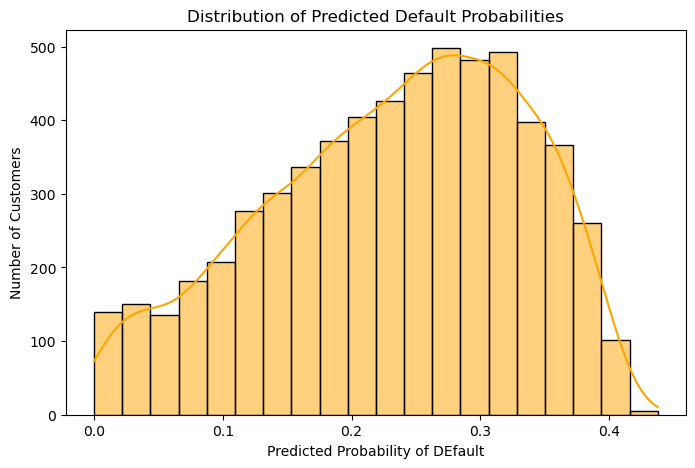

In [64]:
plt.figure(figsize=(8, 5))

sns.histplot(y_pred_test, color='orange', bins=20, kde=True)

plt.title('Distribution of Predicted Default Probabilities')
plt.xlabel('Predicted Probability of DEfault')
plt.ylabel('Number of Customers')

plt.show()

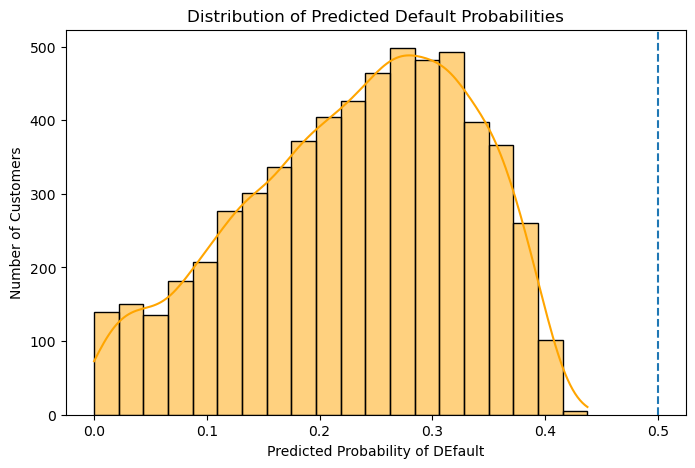

In [65]:
plt.figure(figsize=(8, 5))

sns.histplot(y_pred_test, color='orange', bins=20, kde=True)

plt.axvline(0.5, linestyle='--')

plt.title('Distribution of Predicted Default Probabilities')
plt.xlabel('Predicted Probability of DEfault')
plt.ylabel('Number of Customers')

plt.show()